<div style="text-align: right">INFO 6105 Data Science Eng Methods and Tools</div>
<div style="text-align: right">Final Project</div>

# Bayesian Predictive Modeling for Mortality Risk in Heart Failure Patients

<center>
<img src="ipynb.images/Heart.png" width=700 />
</center

**Link to Dataset used**: [**Mortality-rate-heart-patient**](https://www.kaggle.com/datasets/asgharalikhan/mortality-rate-heart-patient-pakistan-hospital)

### Import Libraries

In [1]:
# importing the libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display_png

RANDOM_SEED = 20090425

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### Data Loading

In [2]:
# Read the dataset and store it in heart_data
heart_data = 'data/heart-data-full.csv'

# Read the dataset into a pandas DataFrame
df = pd.read_csv(heart_data)

In [3]:
# Get information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 60 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               368 non-null    int64  
 1   Age.Group         368 non-null    object 
 2   Gender            368 non-null    object 
 3   Locality          368 non-null    object 
 4   Marital status    368 non-null    object 
 5   Life.Style        368 non-null    object 
 6   Sleep             368 non-null    object 
 7   Category          368 non-null    object 
 8   Depression        368 non-null    object 
 9   Hyperlipi         368 non-null    object 
 10  Smoking           368 non-null    object 
 11  Family.History    368 non-null    object 
 12  F.History         368 non-null    int64  
 13  Diabetes          368 non-null    int64  
 14  HTN               368 non-null    object 
 15  Allergies         368 non-null    object 
 16  BP                368 non-null    float64
 1

In [4]:
# Lets find descriptive statistics for numerical columns in the DataFrame
df.describe()

,Age,F.History,Diabetes,BP,Thrombolysis,BGR,B.Urea,S.Cr,S.Sodium,S.Potassium,...,exang,oldpeak,slope,ca,thal,num,SK,Reaction,Mortality,Follow.Up
count,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,...,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000
mean,54.293478,0.195652,0.461957,121.213315,0.032609,219.991848,51.681522,1.716902,138.019022,4.210870,...,0.562500,1.541848,1.842391,1.002717,5.858696,2.035326,0.983696,0.747283,0.217391,28.652174
std,8.718158,0.397242,0.499229,24.539205,0.177852,139.337387,62.582571,3.609296,4.079879,0.394984,...,0.496754,1.385381,0.564284,1.037442,1.744319,1.031573,0.126816,0.435162,0.413033,15.811860
min,24.000000,0.000000,0.000000,80.500000,0.000000,60.000000,2.300000,0.600000,129.000000,3.300000,...,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,50.750000,0.000000,0.000000,100.700000,0.000000,117.000000,28.000000,0.900000,135.000000,3.900000,...,0.000000,0.275000,1.750000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,15.000000
50%,55.000000,0.000000,0.000000,120.800000,0.000000,164.000000,36.000000,0.900000,138.000000,4.200000,...,1.000000,1.200000,2.000000,1.000000,7.000000,2.000000,1.000000,1.000000,0.000000,32.000000
75%,60.250000,0.000000,1.000000,140.700000,0.000000,291.000000,43.000000,1.100000,141.000000,4.400000,...,1.000000,2.200000,2.000000,2.000000,7.000000,3.000000,1.000000,1.000000,0.000000,36.000000
max,77.000000,1.000000,1.000000,190.110000,1.000000,563.000000,394.000000,22.900000,146.000000,5.300000,...,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000,1.000000,1.000000,60.000000


In [5]:
# Count the number of missing values in each column of the DataFrame
df.isnull().sum()

Age                 0
Age.Group           0
Gender              0
Locality            0
Marital status      0
Life.Style          0
Sleep               0
Category            0
Depression          0
Hyperlipi           0
Smoking             0
Family.History      0
F.History           0
Diabetes            0
HTN                 0
Allergies           0
BP                  0
Thrombolysis        0
BGR                 0
B.Urea              0
S.Cr                0
S.Sodium            0
S.Potassium         0
S.Chloride          0
C.P.K               0
CK.MB               0
ESR                 0
WBC                 0
RBC                 0
Hemoglobin          0
P.C.V               0
M.C.V               0
M.C.H               0
M.C.H.C             0
PLATELET_COUNT      0
NEUTROPHIL          0
LYMPHO              0
MONOCYTE            0
EOSINO              0
Others              0
CO                  0
Diagnosis           0
Hypersensitivity    0
cp                  0
trestbps            0
chol      

### Converting data into numerical

In [6]:
# Identify categorical columns and print their unique values
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

for column in categorical_columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}':",unique_values)
    print()

Unique values in 'Age.Group': ['41-50' '51-60' '61-70' '21-30' '31-40']

Unique values in 'Gender': ['Female' 'Male']

Unique values in 'Locality': ['RURAL' 'URBAN']

Unique values in 'Marital status': ['MARRIED' 'SINGLE']

Unique values in 'Life.Style': ['NO' 'YES']

Unique values in 'Sleep': ['NO' 'YES']

Unique values in 'Category': ['FREE' 'PAID']

Unique values in 'Depression': ['YES' 'NO']

Unique values in 'Hyperlipi': ['YES' 'NO']

Unique values in 'Smoking': ['NO' 'YES']

Unique values in 'Family.History': ['NO' 'YES']

Unique values in 'HTN': ['NO' 'YES']

Unique values in 'Allergies': ['NO' 'YES']

Unique values in 'Others ': ['no' 'LV dysfunction' 'HTN' 'PND, ORTHOPENIA' 'IHD, SOB' 'DM' 'ACS'
 'ICMP WITH EF= 30%,PULMONAR ODEMA' 'CHB, RV INFARCT' 'ORTHOPENIA, PND'
 'HCV, IHD' 'SEIZARIAN, HYSTECTOMY.' 'HTN, DM' 'IHD, HTN'
 'PULMONARY ODEMA ' 'DM,M.I' 'IHD,DM']

Unique values in 'CO': ['Chest pain,' 'Central Chest pain,' 'Chest pain,SOB, Cold sweating'
 'CENTRAL Chest pain,' '

### Data Cleaning and Preprocessing

#### Dropping Columns

After analysis, `Age` proves more precise than `Age.Group` for heart disease. 

Removing less informative features: `Family.History`, `SK.React`, `CO`, `Others `, `Diagnosis`.


In [7]:
# Columns to drop from the DataFrame
columns_to_drop = ['Others ', 'CO', 'Diagnosis', 'SK.React', 'Age.Group', 'Family.History']

# Columns representing binary categorical data to be converted to numerical
binary_columns = ['Life.Style', 'Depression', 'Hyperlipi', 'Smoking', 'HTN', 'Allergies', 'Hypersensitivity', 'Sleep']

clear_df = df.drop(columns=columns_to_drop)

for col in binary_columns:
    clear_df[col] = clear_df[col].map({'YES': 1, 'NO': 0})
    
# Convert other categorical columns to numerical representations
clear_df['Gender'] = clear_df['Gender'].map({'Female': 1, 'Male': 0})
clear_df['Locality'] = clear_df['Locality'].map({'RURAL': 1, 'URBAN': 0})
clear_df['Marital status'] = clear_df['Marital status'].map({'MARRIED': 1, 'SINGLE': 0})
clear_df['Category'] = clear_df['Category'].map({'PAID': 1, 'FREE': 0})

clear_df.head()

,Age,Gender,Locality,Marital status,Life.Style,Sleep,Category,Depression,Hyperlipi,Smoking,...,exang,oldpeak,slope,ca,thal,num,SK,Reaction,Mortality,Follow.Up
0,45,1,1,1,0,0,0,1,1,0,...,1,3.0,2,0,7,2,1,0,0,60
1,51,1,0,1,0,0,0,1,1,0,...,1,1.2,2,0,7,2,1,0,0,15
2,55,1,1,1,1,1,0,1,1,0,...,1,3.4,2,0,3,2,1,0,0,6
3,55,1,1,1,1,1,0,1,1,0,...,1,2.0,2,1,7,3,1,0,0,52
4,56,1,1,1,1,0,0,1,1,0,...,1,4.0,3,2,7,3,1,0,0,34


In [8]:
# Grouping data by 'Gender' and computing descriptive statistics for 'Mortality'
clear_df.groupby('Gender')['Mortality'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
0,285.0,0.161404,0.368550,0.0,0.0,0.0,0.0,1.0
1,83.0,0.409639,0.494757,0.0,0.0,0.0,1.0,1.0


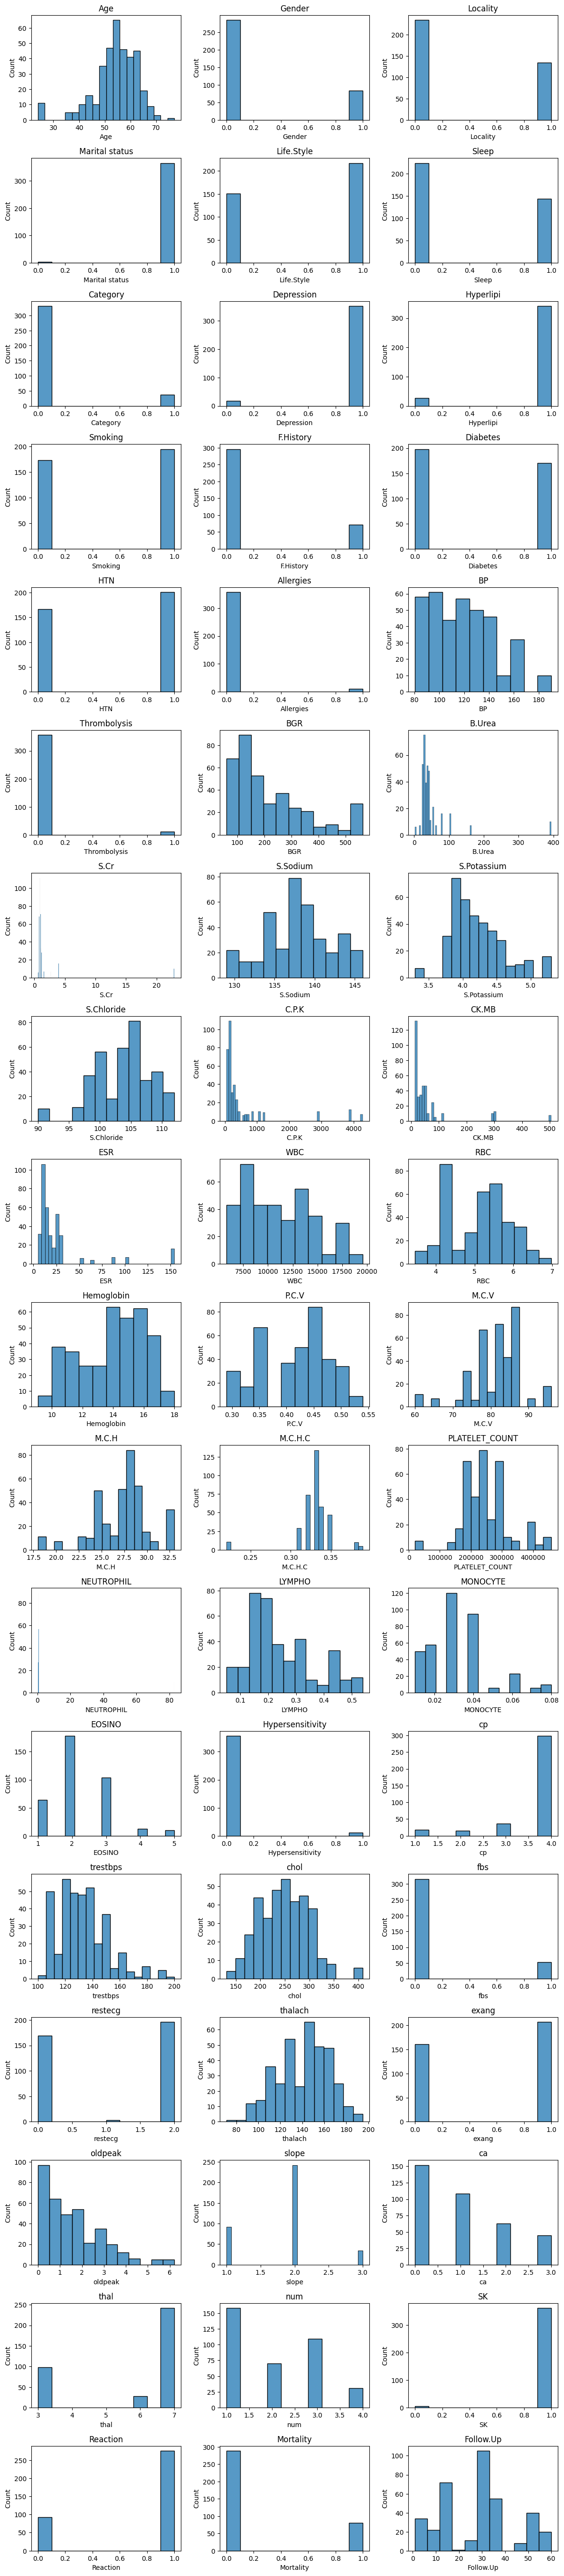

In [9]:
n_cols = 3
n_rows = df.shape[1]

rows_for_subplots = n_rows // n_cols + (n_rows % n_cols > 0)

plt.figure(figsize=(n_cols * 4, rows_for_subplots * 3))

for i, column in enumerate(clear_df.columns):
    plt.subplot(rows_for_subplots, n_cols, i + 1)
    sns.histplot(clear_df[column], kde=False)
    plt.title(column)

plt.tight_layout()

plt.show()

### Exploratory Data Analysis (EDA)

### Mortality Exploration

In [10]:
# Count of unique values in the 'Mortality' (target) column
clear_df['Mortality'].value_counts()

Mortality
0    288
1     80
Name: count, dtype: int64

In [11]:
# Counting instances of patients without mortality (Mortality = 0) and with mortality (Mortality = 1)
countNoMortality = len(clear_df[clear_df.Mortality == 0])
countHaveMortality = len(clear_df[clear_df.Mortality == 1])

# Calculating and printing percentages related to mortality
print("Percentage of Patients without Mortality: {:.2f}%".format((countNoMortality / len(clear_df.Mortality)) * 100))
print("Percentage of Patients with Mortality: {:.2f}%".format((countHaveMortality / len(clear_df.Mortality)) * 100))

Percentage of Patients without Mortality: 78.26%
Percentage of Patients with Mortality: 21.74%


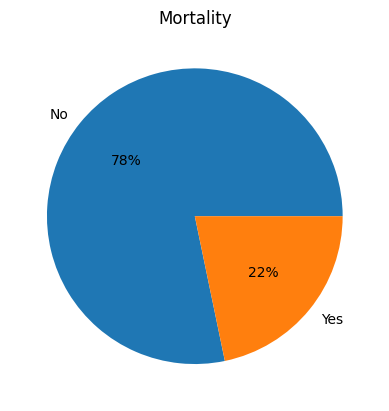

In [12]:
# Creating a pie chart
labels = ['No', 'Yes']
values = clear_df['Mortality'].value_counts().values

plt.pie(values, labels=labels, autopct='%1.0f%%')
plt.title('Mortality')
plt.show()

### Exploring Gender Distribution in Dataset

In [13]:
# Fetching unique values from the 'Gender' column
clear_df['Gender'].unique()

array([1, 0])

In [14]:
clear_df['Gender'].value_counts()

Gender
0    285
1     83
Name: count, dtype: int64

In [15]:
# Counting female and male patients
Female_count = len(clear_df[clear_df.Gender == 1])
Male_count = len(clear_df[clear_df.Gender == 0])

# Calculating and printing percentages
print("Percentage of Female Patients:{:.2f}%".format(Female_count / (len(clear_df.Gender)) * 100))
print("Percentage of Male Patients:{:.2f}%".format(Male_count / (len(clear_df.Gender)) * 100))

Percentage of Female Patients:22.55%
Percentage of Male Patients:77.45%


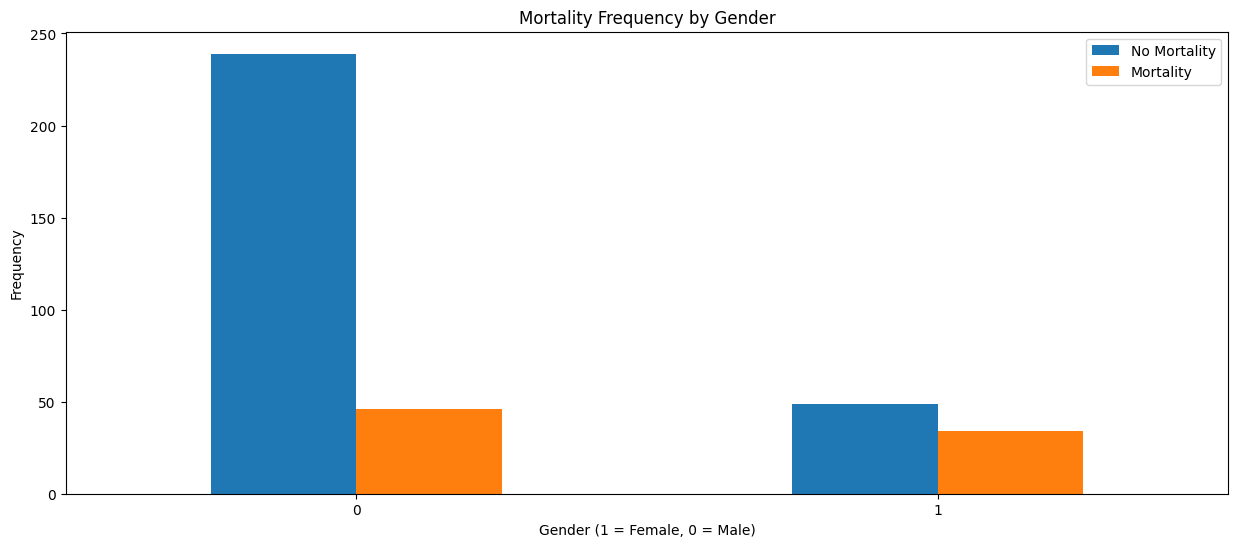

In [16]:
# Plotting the bar chart for Mortality by Gender
pd.crosstab(clear_df.Gender, clear_df.Mortality).plot(kind="bar", figsize=(15,6))

plt.title('Mortality Frequency by Gender')
plt.xlabel('Gender (1 = Female, 0 = Male)')
plt.xticks(rotation=0)
plt.legend(["No Mortality", "Mortality"])
plt.ylabel('Frequency')

plt.show()

In [17]:
cross_tab_data = pd.crosstab(clear_df.Gender, clear_df.Mortality)

# Calculating percentages for males and females with and without mortality
male_have_mortality_percentage = (cross_tab_data.loc[0, 1] / Male_count) * 100
male_no_mortality_percentage = (cross_tab_data.loc[0, 0] / Male_count) * 100

female_have_mortality_percentage = (cross_tab_data.loc[1, 1] / Female_count) * 100
female_no_mortality_percentage = (cross_tab_data.loc[1, 0] / Female_count) * 100

# Printing the percentages related to mortality
print(f"Percentage of Males with mortality: {male_have_mortality_percentage:.2f}%")
print(f"Percentage of Males without mortality: {male_no_mortality_percentage:.2f}%")
print(f"Percentage of Females with mortality: {female_have_mortality_percentage:.2f}%")
print(f"Percentage of Females without mortality: {female_no_mortality_percentage:.2f}%")

Percentage of Males with mortality: 16.14%
Percentage of Males without mortality: 83.86%
Percentage of Females with mortality: 40.96%
Percentage of Females without mortality: 59.04%


### Exploring Chest Pain Types in Dataset

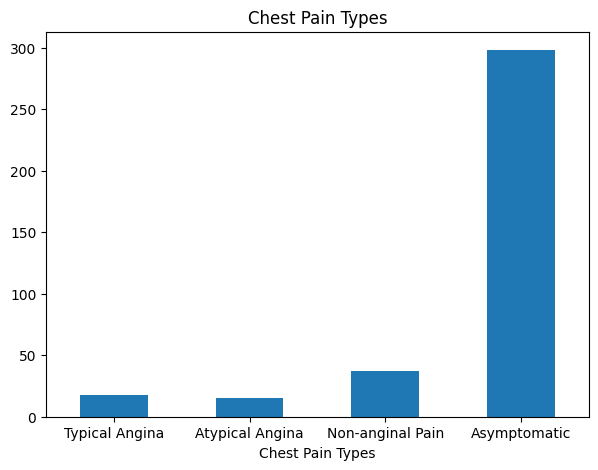

In [18]:
# Grouping by 'cp' (Chest Pain Types) and counting occurrences, then plotting the bar chart
clear_df.groupby(clear_df['cp']).count()['Mortality'].plot(kind='bar', title='Chest Pain Types', figsize=(7, 5))

# Labeling the plot
plt.xlabel('Chest Pain Types')
plt.xticks(np.arange(4), ('Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'), rotation=0)

# Displaying the plot
plt.show()

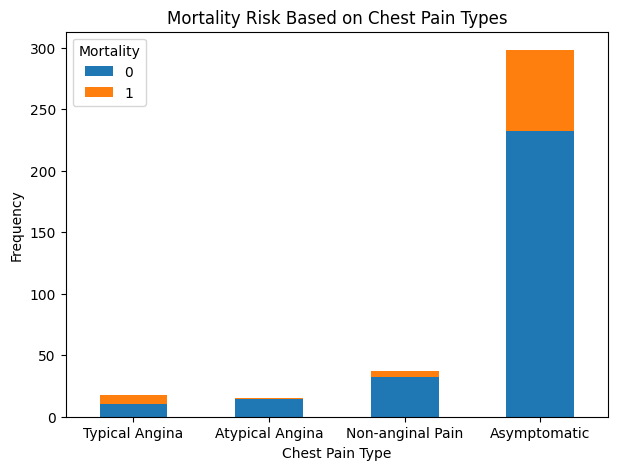

In [19]:
# Plotting the stacked group chart for Mortality by Chest Pain Type
pd.crosstab(clear_df.cp, clear_df.Mortality).plot(kind="bar", stacked = True, figsize=(7, 5))

# Adding a title that reflects the context
plt.title('Mortality Risk Based on Chest Pain Types')
plt.xlabel('Chest Pain Type')
plt.xticks(np.arange(4), ('Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic'), rotation=0)
plt.ylabel('Frequency')

# Displaying the plot
plt.show()


**We can see that most of the people who has heart disease are likely to have Typical Angina chest pain.**

### Exploring Maximum heart rate for patients in Dataset

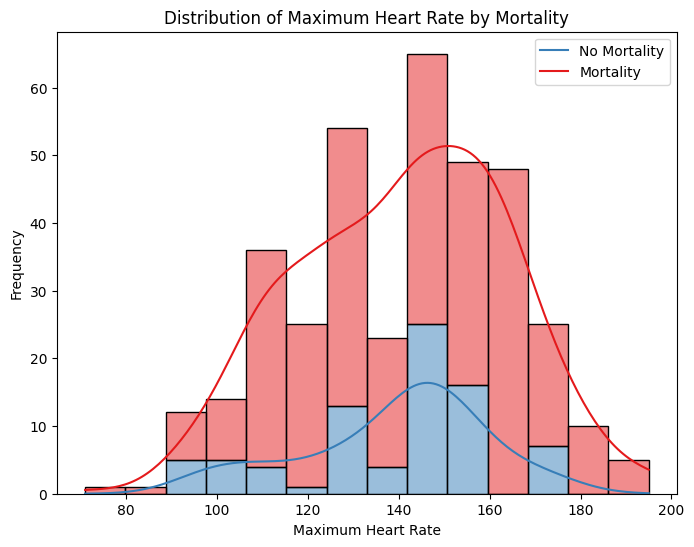

In [20]:
# Plotting the histogram of maximum heart rate for patients with and without mortality using Seaborn
plt.figure(figsize=(8, 6))
sns.histplot(data=clear_df, x='thalach', hue='Mortality', kde=True, multiple='stack', palette='Set1')
plt.title('Distribution of Maximum Heart Rate by Mortality')
plt.xlabel('Maximum Heart Rate')
plt.ylabel('Frequency')
plt.legend(['No Mortality', 'Mortality'])
plt.show()

**We see that people with a higher maximum heart rate are more likely to die. The highest frequency of deaths is among people with a maximum heart rate of 140-160 beats per minute**

In [21]:
# Count the number of patients with mortality (Mortality = 1) and without mortality (Mortality = 0)
n_mortality = clear_df['Mortality'][clear_df['Mortality'] == 1].count()  # Count of patients with mortality
n_no_mortality = clear_df['Mortality'][clear_df['Mortality'] == 0].count()  # Count of patients without mortality
total_patients = clear_df['Mortality'].count()  # Total count of patients in the dataset

# Display the counts for patients with mortality, without mortality, and the total count of patients
n_mortality, n_no_mortality, total_patients

(80, 288, 368)

In [22]:
data_means = clear_df.groupby('Mortality').mean()
data_means

data_variance = clear_df.groupby('Mortality').var()
data_variance

,Age,Gender,Locality,Marital status,Life.Style,Sleep,Category,Depression,Hyperlipi,Smoking,...,thalach,exang,oldpeak,slope,ca,thal,num,SK,Reaction,Follow.Up
Mortality,,,,,,,,,,,,,,,,,,,,,
0,78.020906,0.141684,0.222997,0.010344,0.241386,0.235192,0.073739,0.049543,0.070799,0.245536,...,567.412118,0.242693,2.093233,0.341463,0.960463,3.117257,1.098529,0.02047,0.152875,243.239983
1,66.154430,0.247468,0.252532,0.000000,0.249209,0.250633,0.146203,0.024684,0.059335,0.237342,...,391.149367,0.251741,1.203285,0.237342,1.382120,2.804430,0.888449,0.00000,0.253006,240.379114


In [23]:
# Means for Mortality
mortality_gender_mean = data_means['Gender'][data_variance.index == 1].values[0]
mortality_cp_mean = data_means['cp'][data_variance.index == 1].values[0]
mortality_thalach_mean = data_means['thalach'][data_variance.index == 1].values[0]

# Variance for Mortality
mortality_gender_variance = data_variance['Gender'][data_variance.index == 1].values[0]
mortality_cp_variance = data_variance['cp'][data_variance.index == 1].values[0]
mortality_thalach_variance = data_variance['thalach'][data_variance.index == 1].values[0]

# Means for no Mortality
no_mortality_gender_mean = data_means['Gender'][data_variance.index == 0].values[0]
no_mortality_cp_mean = data_means['cp'][data_variance.index == 0].values[0]
no_mortality_thalach_mean = data_means['thalach'][data_variance.index == 0].values[0]

# Variance for no Mortality
no_mortality_gender_variance = data_variance['Gender'][data_variance.index == 0].values[0]
no_mortality_cp_variance = data_variance['cp'][data_variance.index == 0].values[0]
no_mortality_thalach_variance = data_variance['thalach'][data_variance.index == 0].values[0]

In [24]:
def p_x_given_y(x, mean_y, variance_y):
    
    # Input the arguments into a probability density function
    p = 1/(np.sqrt(2*np.pi*variance_y)) * np.exp((-( x - mean_y)**2) / (2 * variance_y))
    
    # return p
    return p

# Define the function to calculate posterior probabilities for mortality and no mortality
def calculate_posterior_probability(gender, cp, thalach):
    P_mortality_posterior = P_mortality_prior * \
        p_x_given_y(gender, mortality_gender_mean, mortality_gender_variance) * \
        p_x_given_y(cp, mortality_cp_mean, mortality_cp_variance) * \
        p_x_given_y(thalach, mortality_thalach_mean, mortality_thalach_variance)

    P_no_mortality_posterior = P_no_mortality_prior * \
        p_x_given_y(gender, no_mortality_gender_mean, no_mortality_gender_variance) * \
        p_x_given_y(cp, no_mortality_cp_mean, no_mortality_cp_variance) * \
        p_x_given_y(thalach, no_mortality_thalach_mean, no_mortality_thalach_variance)

    return P_mortality_posterior, P_no_mortality_posterior

# Define the interactive function for visualization
def interactive_mortality_probability(gender='Male', cp=1, thalach=0):
    # Map the descriptive labels to numeric values
    gender_mapping = {'Male': 0, 'Female': 1}
    gender_numeric = gender_mapping[gender]
    
    P_mortality_posterior, P_no_mortality_posterior = calculate_posterior_probability(gender_numeric, cp, thalach)
    
    labels = ['Mortality', 'No Mortality']
    values = [P_mortality_posterior, P_no_mortality_posterior]

    plt.bar(labels, values, color=['red', 'green'])
    plt.title('Probability of Mortality or No Mortality')
    plt.xlabel('Status')
    plt.ylabel('Probability')
    plt.show()

In [25]:
P_mortality_prior = n_mortality/total_patients
P_no_mortality_prior = n_no_mortality/total_patients

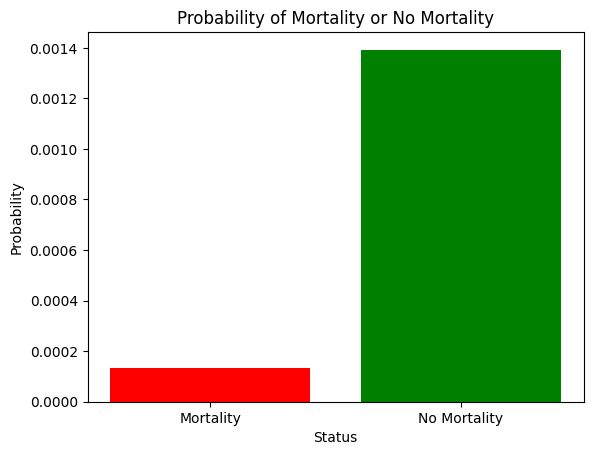

interactive(children=(Dropdown(description='Gender:', options=('Male', 'Female'), value='Male'), Dropdown(desc…

<function __main__.interactive_mortality_probability(gender='Male', cp=1, thalach=0)>

In [26]:
# Interactive visualization with widgets
cp_dropdown = Dropdown(options=[4,3,2,1], value=4, description='Chest Pain Type:')
gender_dropdown = Dropdown(options=['Male', 'Female'], value='Male', description='Gender:')
thalach_slider = IntSlider(min=70, max=200, step=10, value=100, description='Maximum Heart Rate (thalach):')

interact(interactive_mortality_probability, gender=gender_dropdown, cp=cp_dropdown, thalach=thalach_slider)

**Amazing!!!!**